In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Embedding, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [18]:
df = pd.read_csv("imdb.csv", encoding='latin1')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [27]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

In [35]:
texts = [text.replace("<br />", "") for text in df['review'].values]
labels = LabelEncoder().fit_transform(df['sentiment'].values)

In [36]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded = pad_sequences(sequences,maxlen=200,padding='post', truncating='post')

In [47]:
x_train, x_test, y_train, y_test = train_test_split(padded, labels, test_size=0.3, random_state=42)

In [64]:
model = Sequential([
    Embedding(input_dim=10000, output_dim=64, input_length=200),
    GlobalAveragePooling1D(),
    Dense(16, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [65]:
model.build(input_shape=(None, 200))
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641,057 (2.45 MB)

 Trainable params: 641,057 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
early_stopping= EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=20, batch_size=32, callbacks=early_stopping)

Epoch 1/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6654 - loss: 0.5951 - val_accuracy: 0.8515 - val_loss: 0.3450
Epoch 2/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8729 - loss: 0.3347 - val_accuracy: 0.8777 - val_loss: 0.2992
Epoch 3/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.8967 - loss: 0.2812 - val_accuracy: 0.8547 - val_loss: 0.3386
Epoch 4/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9101 - loss: 0.2552 - val_accuracy: 0.8823 - val_loss: 0.2880
Epoch 5/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.9209 - loss: 0.2275 - val_accuracy: 0.8796 - val_loss: 0.3115
Epoch 6/20
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9250 - loss: 0.2201 - val_accuracy: 0.8728 - val_loss: 0.3281


In [67]:
model.evaluate(x_test, y_test)

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8834 - loss: 0.2824


[0.2879919409751892, 0.882266640663147]

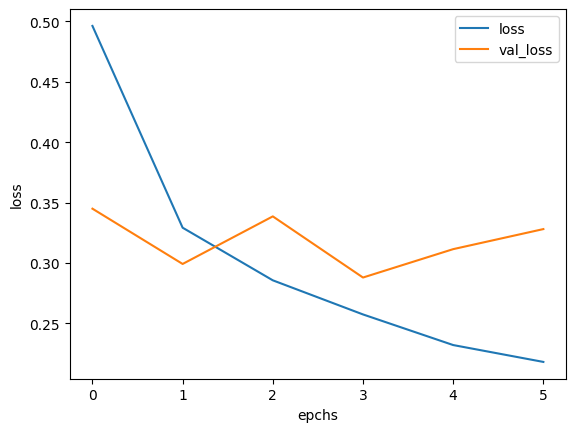

In [68]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.xlabel('epchs')
plt.ylabel('loss')
plt.legend()

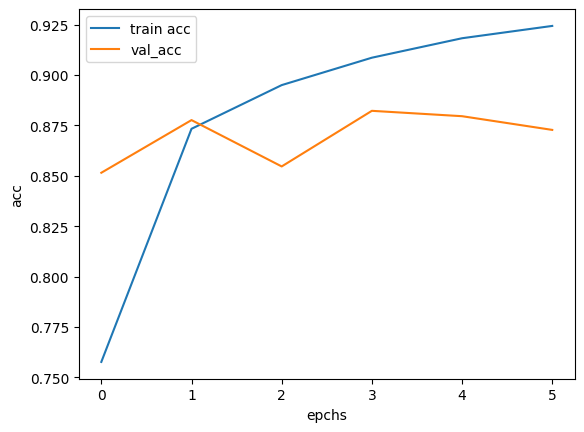

In [69]:
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'],label='val_acc')
plt.xlabel('epchs')
plt.ylabel('acc')
plt.legend()

In [71]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, recall_score, precision_score
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)
print(confusion_matrix(y_test, y_pred))

print(accuracy_score(y_test, y_pred))
print(f1_score(y_test, y_pred))
print(precision_score(y_test, y_pred))

469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[6471  940]
 [ 826 6763]]
0.8822666666666666
0.8845147789693958
0.8779696222251071


In [77]:

sample_review = "This movie was amazing, I did loved any bit of it!"
# Step 1: Preprocess
sample_seq = tokenizer.texts_to_sequences([sample_review])
sample_pad = pad_sequences(sample_seq, maxlen=200, padding='post', truncating='post')

# Step 2: Predict
prediction = model.predict(sample_pad)

# Step 3: Interpret
print(f"Confidence Score: {prediction[0][0]}")
if prediction[0][0] > 0.5:
    print("Predicted Sentiment: Positive 😊")
else:
    print("Predicted Sentiment: Negative 😞")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Confidence Score: 0.82009357213974
Predicted Sentiment: Positive 😊


In [ ]:

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten, Dropout, LSTM
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

#

df = pd.read_csv(r"imdb.csv", encoding='latin1')
df

#

df.isnull().sum()

#

# Label Encoding: Convert 'positive' to 1 and 'negative' to 0
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
df

#


# Splitting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['sentiment'], test_size=0.2, random_state=42)

# Text Preprocessing: Tokenization & Padding
vocab_size = 10000  # Number of unique words to keep
max_length = 200  # Max review length
oov_token = "<OOV>"  # Out of vocabulary token

# Initialize Tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_token)
tokenizer.fit_on_texts(X_train)

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform input size
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')

# Build the Deep Neural Network Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),  # Embedding layer
    LSTM(64, return_sequences=True),  # LSTM layer for sequential data
    LSTM(32),  # Another LSTM layer
    Dropout(0.5),  # Dropout to prevent overfitting
    Dense(32, activation='relu'),  # Dense hidden layer
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the Model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the Model
history = model.fit(X_train_pad, y_train, epochs=20, batch_size=32, validation_data=(X_test_pad, y_test))

# Evaluate the Model
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)  # Convert probabilities to binary labels

#

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))

# Analyze Misclassifications
misclassified_idx = np.where(y_pred.flatten() != y_test.values)[0]
print(f"Number of Misclassified Samples: {len(misclassified_idx)}")
print("\nSome Misclassified Reviews:")
for i in misclassified_idx[:5]:  # Show 5 misclassified reviews
    print("\nReview:", X_test.iloc[i])
    print("True Sentiment:", "Positive" if y_test.iloc[i] == 1 else "Negative")
    print("Predicted Sentiment:", "Positive" if y_pred[i] == 1 else "Negative")

#

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.show()

#

sample_review = "This movie was absolutely amazing, I loved every bit of it!"

# Step 1: Preprocess
sample_seq = tokenizer.texts_to_sequences([sample_review])
sample_pad = pad_sequences(sample_seq, maxlen=max_length, padding='post', truncating='post')

# Step 2: Predict
prediction = model.predict(sample_pad)

# Step 3: Interpret
print(f"Confidence Score: {prediction[0][0]}")
if prediction[0][0] > 0.5:
    print("Predicted Sentiment: Positive 😊")
else:
    print("Predicted Sentiment: Negative 😞")


Epoch 1/20


C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 209s 163ms/step - accuracy: 0.5083 - loss: 0.6940 - val_accuracy: 0.5039 - val_loss: 0.6931
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 186s 149ms/step - accuracy: 0.4982 - loss: 0.6938 - val_accuracy: 0.5601 - val_loss: 0.6922
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 185s 148ms/step - accuracy: 0.5186 - loss: 0.6918 - val_accuracy: 0.5219 - val_loss: 0.6903
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 184s 147ms/step - accuracy: 0.5817 - loss: 0.6622 - val_accuracy: 0.8324 - val_loss: 0.3817
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 184s 147ms/step - accuracy: 0.8548 - loss: 0.3540 - val_accuracy: 0.8675 - val_loss: 0.3035
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 682s 531ms/step - accuracy: 0.9064 - loss: 0.2433 - val_accuracy: 0.8759 - val_loss: 0.2895
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 181s 145ms/step - accuracy: 0.9332 - loss: 0.1831 - val_accuracy: 0.8750 - val_loss: 0.3047
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 186s 149ms/step - accuracy: 0.9